# Feedback Control

Since I learned Reinforcement Learning (RL) first, I find it helpful to understand Control Theory by mapping my existing RL knowledge onto control system concepts.

In Reinforcement Learning, the environment is typically treated as a black box. Algorithms infer the system's behavior by observing the relationship between inputs (actions) and outputs (states/rewards) through trial and error, without requiring an explicit mathematical model of the system's internal physics. Consequently, RL relies heavily on data generated through these environmental interactions.

In contrast, Control Theory is traditionally model-based. Even if the exact parameters are unknown, the approach begins by attempting to approximate the system's dynamics mathematically. By leveraging this model, control techniques manipulate inputs to achieve predefined goals, such as maintaining a specific position or "setpoint."

To implement a control strategy, we generally need to:

 - Model the system: Mathematically describe its dynamics if they are not already known.

 - Define the objective: Establish the target state or behavior.

 - Design the control law: Determine how the input should change to reach the goal.

There are two primary types of control architectures:

Feedforward (Open-Loop): The controller sends a command based on a preset model without measuring the result. This requires nearly perfect knowledge of the system, as there is no mechanism to correct for errors or external disturbances.

Feedback (Closed-Loop): The system uses sensors to measure outputs and "feeds" that information back to the controller to adjust the inputs. This is far more robust, as it can compensate for noise, environmental changes, and modeling inaccuracies.

In the following sections, we will use the Cartpole example from the Gymnasium (formerly OpenAI Gym) library to demonstrate these feedback control techniques.


## Cartpole System

A system is usually represented as:
$$ u(t) \rightarrow \boxed{G(s)} \rightarrow y(t) $$
where $y(t)$ is the output of the system and $u(t)$ is the input, and $y = G(u)$.
If the system is said to be time-invariant, so $y-u$ relationship is time independent. 

Then we can represent a dynamic system itself by a state variable at the instance $t$ by $x(t)$.
For a linear system, we have:
$$ \dot{x} (t) = Ax(t) + Bu(t) $$
$$  y(t) = Cx(t) + Du(t) $$
and A, B, C and D are constants independent of t.

But often, we have a non-linear system, so we have to linearize it in the form of the previous equations by determining the A, B, C and D.

For the cartpole example, the dynamics for the system is represented:
$$ \ddot{\theta} = \frac{g sin \theta + cos(\frac{-F - m_p l \dot{\theta}^2 sin \theta}{m_c + m_p})}{l(\frac{4}{3} - \frac{m_p cos^2 \theta}{m_c + m_p})}$$  
$$ \ddot{x} = \frac{F + m_p l (\dot{\theta}^2 sin \theta - \ddot{\theta} cos \theta)}{m_c + m_p} $$ 

where:
 - $\theta$ is the angle between the pole and the vertical line
 - $x$ is the chat position
 - $g$ is the gravity
 - $m_p$ and $m_c$ are the mass of pole and cart respectively
 - $l$ is the pole length
 - $F$ is the input force

And the general State-space model representation for a linear time-invariant system (LTI) is:
 - State Equation: $ \dot{x} = Ax(t) + Bu(t) $
 - Output Equation: $ y(t) = Cx(t) + Du(t) $

And the state vector is :
$$ x = \begin{bmatrix*}[r] 
        x \\[0.5ex]  \dot{x} \\[1ex] \theta \\[1ex] \dot{\theta}
\end{bmatrix*} 
   u = \begin{bmatrix*}[r] 
        F 
\end{bmatrix*}$$
$A$ describs the intrinsic properties of the system and $B$ describs how system responds to the input directly. 
They can be determined by applying Jacobian operations.



In [14]:
import copy
import scipy
import sympy as sy
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from sympy import symbols, Number
from sympy.matrices.dense import matrix2numpy
from cartpole_utils import Agent, test_cartpole, display_frames_as_gif, env_cartpole, HTML

## Naive way to control the pole

An intuitive but naive way to balance the pole is to push the pole towards the side of the angle. 

In [8]:
# naive agent
class NaiveAgent(Agent):
    def __init__(self):
        """
        set the goal at position 1 and angle of 0
        """
        super().__init__()
        self.r = np.array([1,0,0,0])

    def act(self, state, train=False):
        error = self.r - state
        u = error[0]/ 4.8 + error[2]/ 0.41
        action = 1 if u < 0 else 0 # attempt to push the pole to the opposite of the angle
        return action 

    def learn(self):
        pass

In [9]:
nagent = NaiveAgent()
frames = test_cartpole(env_cartpole, 500, agent=nagent)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

/home/niuniu/Documents/RL/env_rl/lib64/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


84


Clearly, this system tries to balance the pole, but it is unstable. 

## LQR


The Control system of Linear Quadratic Regulator (LQR: 
https://medium.com/@prajwalkoirala/feedback-control-of-cart-pole-937e3d3fdc51) looks like:

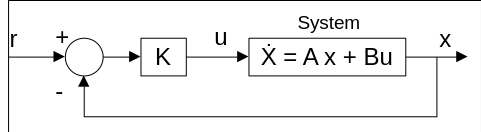

The gain $K$ can be obtained using lqr by minimizing a weighted cost function.
Then the input $u$ is corrected using the gain:
$$u_{new} = k*(x-x_{new})$$

In [11]:
class CartpoleDynamics:
    """
    To describe the cartpole dynamics with a series of 
    differential equations and linerize it using jaccobian operation.
    """
    def __init__(self):
        """
        Initialize cartpole system constants and the differential equations.
        """
        g = 9.8     # state constant gravity
        M = 1.0     # state constant mass of cart
        m = 0.1     # state constant mass of pole
        l = 0.5     # state constant length of pole
        self.x, self.dx, self.theta, self.dtheta, self.u = symbols('x dx theta dtheta u')         # state variables

        self.ddtheta = (g * sy.sin(self.theta)-(self.u + l * self.dtheta**2 * sy.sin(self.theta) * m)/(M+m)*sy.cos(self.theta))/(l*(4.0/3.0-(sy.cos(self.theta))**2 * m/(m+M)))
        self.ddx = (self.u + m*l*(self.dtheta**2 * sy.sin(self.theta) - self.ddtheta * sy.cos(self.theta))) / (m + M)
        

    def eval_func(self, x, dx, te, dte, u):
        """To evaluate the differential equations by injecting
        variables' values.
        """
        ddx = self.ddx.evalf(subs={self.x:x, 
                             self.dx:dx, 
                             self.theta:te, 
                             self.dtheta:dte, 
                             self.u:u})
        ddtheta = self.ddtheta.evalf(subs={self.x:x, 
                                     self.dx:dx, 
                                     self.theta:te, 
                                     self.dtheta:dte, 
                                     self.u:u})
        return ddx, ddtheta   
        
    
    def jacobian(self, eval=False, **kwargs):
        """
        linearize the non-linear dynamic functions.
        """
        func = sy.Matrix([self.dx, self.ddx, self.dtheta, self.ddtheta]) # the nonlinear functions of state variables and u
        A = func.jacobian([self.x, self.dx, self.theta, self.dtheta])
        B = func.jacobian([self.u])

        if not eval:
            return A, B
        else:
            if any(item not in kwargs.keys() for item in ['x', 'dx', 'theta', 'dtheta']) :
                raise ("Keyword arguments are not complete.")
            else:
                return matrix2numpy(A.evalf(subs={self.x:kwargs['x'], 
                                                  self.dx:kwargs["dx"], 
                                                  self.theta:kwargs["theta"], 
                                                  self.dtheta:kwargs["dtheta"], 
                                                  self.u:kwargs["u"]}), dtype=float), \
                matrix2numpy(B.evalf(subs={self.x:kwargs['x'], 
                                           self.dx:kwargs["dx"], 
                                           self.theta:kwargs["theta"], 
                                           self.dtheta:kwargs["dtheta"], 
                                           self.u:kwargs["u"]}), dtype=float)
            
    def __str__(self):
        round_expr = lambda expr, digits: expr.xreplace({n : round(n, digits) for n in expr.atoms(Number)})
        str = ""
        str += f"ddtheta = {round_expr(self.ddtheta, 3)}\n"
        str += f"ddx = {round_expr(self.ddx, 3)}\n"
        A, B = self.jacobian()
        str += "A = "
        for i in range(4):
            str += f"{round_expr(A, 3)[i,:]}\n"
        str += "B = "
        for i in range(4):
            str += f"{round_expr(B, 3)[i,:]}\n"
        return str

In [17]:
class KControlAgent(Agent):
    """
    Agent based aon gain only feedback control.
    """
    def __init__(self, Q, R, r):
        """
        Initialize gain control related variables.
        Args:
            Q list[4]: penalizations for the feeds: pos, vel, angle, ang vel
            R list1]: penalization for the input: force
            r list[4]: target
        """
        super().__init__()
        self.cartpole_dynamics = CartpoleDynamics()
        self.r = r
        self.states = []
        self.forces = []

        # linerize the non-linear system
        init_conds = {'x':0.0, 'dx':0.0, 'theta':0.0, 'dtheta':.0, 'u':0.5}
        A, B = self.cartpole_dynamics.jacobian(eval=True, **init_conds)

        # find the gain K to minimlize the cost function lqr
        K, X, eigVals = lqr(A,B,Q,R)
        self.K = K

    def act(self, state, train=False):
        """
        Function to control the cartpole in action. It's called
        at each iteration of the game.
        Args:
            state List: the state variables of the cartpole game (the feedback variables).
            train (bool, optional): To indicate if it's for training. Defaults to False.

        Returns:
            float: signed force value.
        """
        error = self.r - state
        force = np.dot(self.K, error)
        action = 0 if force < 0 else 1
        self.states.append(state)
        self.forces.append(np.dot(self.K, error))
        return action 

    def plot(self):
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1)
        states = np.array(self.states).T
        ax1.plot(states[0])
        ax1.set_title("Position")
        ax2.plot(states[1])
        ax2.set_title("Velocity")
        ax3.plot(states[2])
        ax3.set_title("Angle")
        ax4.plot(self.forces)
        ax4.set_title("Force")

    
def lqr(A,B,Q,R):
    """
    https://codepal.ai/code-generator/query/RwQYplhh/optimal-values-q-r-lqr-controller-python#google_vignette
    """
    R = np.eye(1) * R
    X = np.matrix(scipy.linalg.solve_continuous_are(A, B, Q, R)) # solve the ricatti equation
    K = np.matrix(scipy.linalg.inv(R) * (B.T * X)) # compute the LQR gain
    eigVals, eigVecs = scipy.linalg.eig(A-B * K)
     
    return np.asarray(K)[0], X, eigVals

In [23]:
# set the control system
Q = np.diag([1., 0.001, 1., 0.01]) # penalize the angular error, higher value penalize more
R = 0.001  # penalize the input force
r = np.array([-1., 0., 0., 0.]) # goal for the state: position at -1
cagent = KControlAgent(Q, R, r)
A, B = cagent.cartpole_dynamics.jacobian(eval=True, x=0.0, dx=0.0, theta=0.0, dtheta=.0, u=0.5)
print(f"A = {A}\nB = {B}\n")
print(f"K = {cagent.K}")

# generate animation
frames = test_cartpole(env_cartpole, 500, agent=cagent)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

A = [[ 0.          1.          0.          0.        ]
 [ 0.          0.         -0.71707317  0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.          0.         15.77560976  0.        ]]
B = [[ 0.        ]
 [ 0.97560976]
 [ 0.        ]
 [-1.46341463]]

K = [ -31.6227766   -26.21350584 -117.09971684  -29.37814346]


/home/niuniu/Documents/RL/env_rl/lib64/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


501


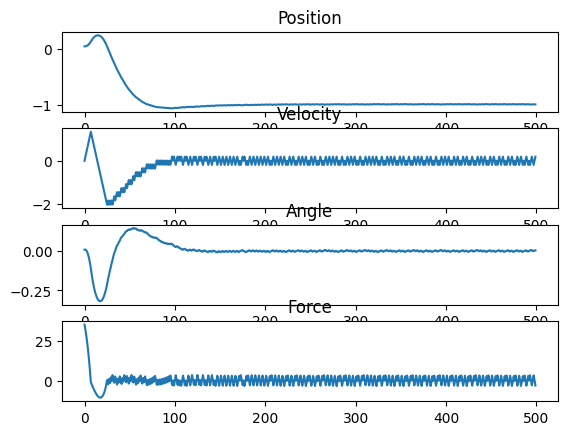

In [24]:
cagent.plot()

It seems a simple gain works very good, yet remain very simple. But this is based on the fact that the system was relatively well modeled. $r$ controls the speed of attaining the goal (lower the value, faster the pole reaches the position -1) and Q controls the overshoot to get to the goal (lower the value, higher deviation from the target values the system is allowed wile reaching the target). Thus, Q can influence the stability of the system.
If we set the Q[3] to 0.001 which penalizes the angular velocity, the system will fail due to the higher angular deviation.

## PID

For single gain control, it is hard to control the speed of goal achieving and system stability. So instead of using a simple gain controller like LQR, we can use a controller that maximize the speed while keeping the system stable. PID as its name indicates is composed of a proportional, an integral and a derivative components. Essentially, the integral component helps the system overcome the residue error (normally due to the system modeling error or the environment influences, which is not present in the CartPole example) and the derivative component prevents the overshoot, thus stabilize the system.

In [25]:
class PIDControlAgent(Agent):
    """
    Agent for cartpole control using PID control.
    """
    def __init__(self, Q, R, r):
        """
        Initialize constants for PID control. Same as gain control, but Q and R are not used here.
        """
        super().__init__()
        self.r = r

        # empirical values for the gain values of each control unit.
        self.Kp = np.array([-50, -0.1, -400, -0.01])        # proportional gain
        self.Ki = np.array([-1.0, -1.0, -10.6, -1.0])       # integral gain
        self.Kd = np.array([-100.2, -0.1, -1000.0, -1.0])   # derivative gain

        self.old_error = np.array([0,0,0,0])

        self.states = []
        self.forces = []
        self.integral = 0

    def act(self, state, train=False):
        """
        Function to control the cartpole in action. It's called
        at each iteration of the game.
        Args:
            state List: the state variables of the cartpole game (the feedback variables).
            train (bool, optional): To indicate if it's for training. Defaults to False.

        Returns:
            float: signed force value.
        """
        error = self.r - state
        self.integral += error
        force = np.dot(self.Kp, error) + np.dot(self.Kd, error-self.old_error) + np.dot(self.Ki, self.integral)
        action = 0 if force < 0 else 1
        self.old_error = error
        self.states.append(state) # for plot
        self.forces.append(np.dot(self.Kp, error)) # for plot
        return action 

    def plot(self):
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1)
        states = np.array(self.states).T
        ax1.plot(states[0])
        ax1.set_title("Position")
        ax2.plot(states[1])
        ax2.set_title("Velocity")
        ax3.plot(states[2])
        ax3.set_title("Angle")
        ax4.plot(self.forces)
        ax4.set_title("Force")

In [27]:
Q = np.diag([1., 0.001, 1., 0.001]) # same as LQR
R = 0.001 # same as LQR
r = np.array([-1, 0., 0., 0.]) # goal for the state: position at -1

pidagent = PIDControlAgent(Q, R, r)
frames = test_cartpole(env_cartpole, 500, agent=pidagent)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

/home/niuniu/Documents/RL/env_rl/lib64/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


501


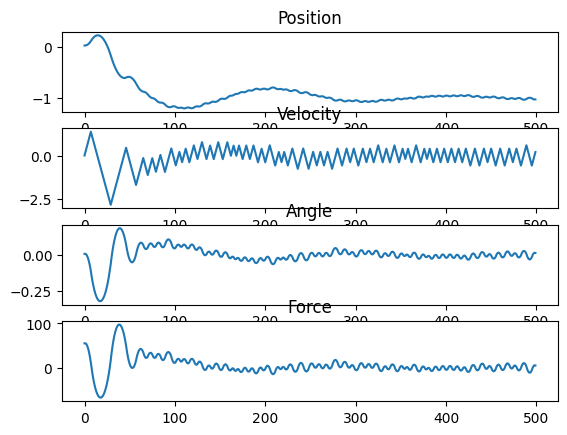

In [28]:
pidagent.plot()

PID for CartPole is clearly a overkill, since there is no systematic error in this system, neither a significant overshoot if there is no constraint for speed. PID needs more complicated design process to find the optimal gains.

But we can see that for penalization that distabilize the system using LQR, PID allows to achieve the goal without problems.

## MPC

Model Predictive Control(MPC) is a path planning technique. At each step it uses a cost function to compute the optimal path in a time frame (horizon) and apply only the first action of the optimal path.

$$J(u) = \int_{0}^{T}{Q_x(x(t) - x_{ref})^2 + R^T u(t)^2) dt} $$

In [101]:
def next(self, state, u, dt):
    """
    To calculate the next state of a cart-pole system based on the current state, control input `u`, and time step `dt`.
    This is not used here.
    """
    ddx, ddtheta = self.eval_func(*state, u*100.0)
    temp = np.array([state[1], ddx, state[3], ddtheta])
    next_state = state + temp * dt
    return next_state

CartpoleDynamics.next = next # add method to CartpoleDynamics class

In [47]:
import numpy as np
from scipy.optimize import minimize

class MPCControlAgent(Agent):
    def __init__(self, horizon, Q, R, r):
        """
        Initialize the MPC controller.
        Args:
            env: The gym environment for the cart-pole.
            horizon: The prediction horizon for the MPC.
            Q: The state weighting matrix.
            R: The control input weighting matrix.
            r: The targets.
        """
        super().__init__()
        self.horizon = horizon
        self.Q = Q
        self.R = R
        self.r = r
        self.action_dim = 1  # Control input is a single continuous value (force)
        self.cpdynamics = CartpoleDynamics() #  this sympy version not used, too slow, if use this run the previous cell to add the next method.
        self.prev_optimal_actions = np.zeros(self.horizon)
        self.states = []
        self.forces = []

    def dynamics(self, state, action, tau):
        """
        Predict the next state using the cart-pole dynamics.
        We could have used the eval_func method of CartpoleDynamics class, but since it's defined symbolically and use use evalf function which is very slow and we need to compute the derivatives 'horizon' times per iteration, the control process will be really slow. So we sue the numerical version of the derivatives to speed up the computation.
        """
        gravity = 9.8
        masscart = 1.0
        masspole = 0.1
        total_mass = masscart + masspole
        length = 0.5  # actually half the pole's length

        x, dx, theta , dtheta = state
        u = action * 100

        ddtheta = (gravity * np.sin(theta)-(u + length * dtheta**2 * np.sin(theta) * masspole)/(total_mass)*np.cos(theta))/(length*(4.0/3.0-(np.cos(theta))**2 * masspole/total_mass))
        ddx = (u + masspole*length*(dtheta**2 * np.sin(theta) - ddtheta * np.cos(theta))) / total_mass

        x_next = x + tau * dx
        x_dot_next = dx + tau * ddx
        theta_next = theta + tau * dtheta
        theta_dot_next = dtheta + tau * ddtheta

        return np.array([x_next, x_dot_next, theta_next, theta_dot_next])


    def cost_function(self, actions, initial_state):
        """
        Calculate the total cost for a sequence of actions.
        """
        cost = 0.0
        state = initial_state
        for action in actions:
            state = self.dynamics(state, action, 0.1)
            cost += np.dot((self.r-state).T, np.dot(self.Q, (self.r-state))) \
                 + np.dot(action, np.dot(self.R, action))
        return cost

    def act(self, state, train=False):
        """
        Get the optimal action for the current state.
        Args:
            state: The current state of the system.
        Returns:
            int: The optimal control action.
        """
        # Initial guess for the actions
        initial_actions = np.roll(self.prev_optimal_actions, -1)
        initial_actions[-1] = 0

        # Solve the optimization problem
        result = scipy.optimize.minimize(
            self.cost_function,
            initial_actions,
            args=(state,),
            method='SLSQP',
            bounds=[(-1.0, 1.0)] * self.horizon
        )

        # Get the optimal actions and return the first one
        self.prev_optimal_actions = result.x
        u = 1 if self.prev_optimal_actions[0] > 0 else 0

        self.states.append(state)
        self.forces.append(self.prev_optimal_actions[0])

        # Return the first action of the optimal sequence
        return u

    def plot(self):
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1)
        states = np.array(self.states).T
        ax1.plot(states[0])
        ax1.set_title("Position")
        ax2.plot(states[1])
        ax2.set_title("Velocity")
        ax3.plot(states[2])
        ax3.set_title("Angle")
        ax4.plot(self.forces)
        ax4.set_title("Force")

In [ ]:
horizon = 10
Q = np.diag([1.0, 0.001, 1.0, 0.01])
R = 0.001
r = np.array([-1, 0., 0., 0.]) 

mpcagent = MPCControlAgent(horizon, Q, R, r)

frames = test_cartpole(env_cartpole, 500, agent=mpcagent)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

/home/niuniu/Documents/RL/env_rl/lib64/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


501


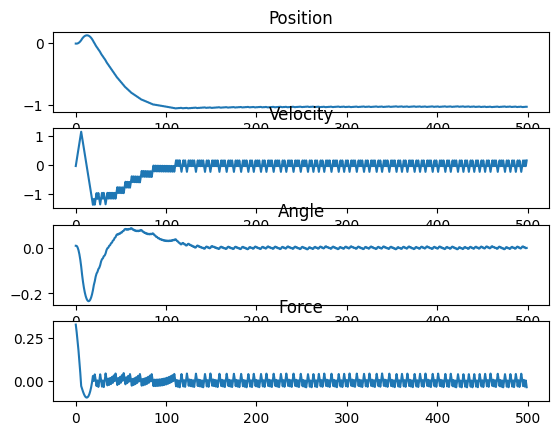

In [51]:
mpcagent.plot()

The technique seems robust but slow. Also, the cost function to minimize plays a crucial role for the performance of MPC. When the system becomes complex and the number of performance factors is large, it may be hard to find the optimal cost function.

https://www.youtube.com/playlist?list=PLW4eqbV8qk8b7WLDXM2mTFZDSbm685Rjy